## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [4]:
MONTH = 'July'
PERIOD = '1st'

In [5]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-{MONTH}-{PERIOD}_filled.csv', encoding=enc)

In [6]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79539,45.35783,2023-07-01,2023,7,2023-06-27,45.358184,11.797125,0.300855,0.069678,-0.278981,-0.069678,0.351339,0.082489,-0.324716,-0.082489,0.064731,0.039651,0.053531,0.039651,2023-06-28,45.358184,11.797125,15643.0,14872.0,45.358184,11.797125,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,2023-07-01,45.350207,11.750054,331.329827,2023-06-24,2023-06-17,2023-06-24,2023-06-17,16.982731,20.809081
1,adria,veneto,12.03247,45.07647,2023-07-01,2023,7,2023-06-27,45.075215,12.030687,0.406662,0.141095,-0.434892,-0.141095,0.356033,0.129478,-0.363739,-0.129478,0.045353,0.033132,0.033093,0.033132,2023-06-28,45.075215,12.030687,15461.0,14733.0,45.075215,12.030687,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,2023-07-01,45.050206,12.050055,573.420141,2023-06-24,2023-06-17,2023-06-24,2023-06-17,45.185285,45.318445
2,adria,veneto,12.05787,45.05851,2023-07-01,2023,7,2023-06-27,45.057249,12.057637,0.185439,-0.042404,-0.209365,0.042404,0.225242,-0.010909,-0.247437,0.010909,0.030697,0.031293,0.030123,0.031293,2023-06-28,45.057249,12.057637,15672.0,14844.0,45.057249,12.057637,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,2023-07-01,45.050206,12.050055,573.420141,2023-06-24,2023-06-17,2023-06-24,2023-06-17,45.185285,45.318445
3,adria,veneto,12.05787,45.07647,2023-07-01,2023,7,2023-06-27,45.075215,12.057637,0.317368,0.064761,-0.334694,-0.064761,0.334881,0.095122,-0.347670,-0.095122,0.118328,0.113735,0.079274,0.113735,2023-06-28,45.075215,12.057637,15507.0,14695.0,45.075215,12.057637,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,2023-07-01,45.050206,12.050055,573.420141,2023-06-24,2023-06-17,2023-06-24,2023-06-17,45.185285,45.318445
4,affi,veneto,10.77673,45.55680,2023-07-01,2023,7,2023-06-27,45.555814,10.777538,0.374134,0.077508,-0.365619,-0.077508,0.492121,0.137722,-0.442508,-0.137722,0.105580,0.048572,0.078717,0.048572,2023-06-28,45.555814,10.777538,15197.0,14792.0,45.555814,10.777538,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,2023-07-01,45.550208,10.750049,160.042990,2023-06-24,2023-06-17,2023-06-24,2023-06-17,0.000000,2.272969


In [7]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
cols = dataset.columns
cols

Index(['lau1', 'nuts2', 'x', 'y', 'dt_placement', 'year', 'month',
       'indices_image_date', 'indices_lat', 'indices_lon', 'ndvi', 'ndmi',
       'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
       'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_image_date',
       'lst_lat', 'lst_lon', 'lst_day', 'lst_night', 'monthly_lst_lat',
       'monthly_lst_lon', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'indices_image_date.1', 'indices_lat.1', 'indices_lon.1',
       'acc_rainfall_jan', 'dt_placement_minus_7', 'dt_placement_minus_14',
       'dt_placement_minus_7_avail', 'dt_placement_minus_14_avail',
       'acc_rainfall_1week', 'acc_rainfall_2week'],
      dtype='object')

In [9]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [11]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79539,45.35783,2023-07-01,2023,7,0.300855,0.069678,-0.278981,-0.069678,0.351339,0.082489,-0.324716,-0.082489,0.064731,0.039651,0.053531,0.039651,15643.0,14872.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,331.329827,16.982731,20.809081
1,adria,veneto,12.03247,45.07647,2023-07-01,2023,7,0.406662,0.141095,-0.434892,-0.141095,0.356033,0.129478,-0.363739,-0.129478,0.045353,0.033132,0.033093,0.033132,15461.0,14733.0,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,573.420141,45.185285,45.318445
2,adria,veneto,12.05787,45.05851,2023-07-01,2023,7,0.185439,-0.042404,-0.209365,0.042404,0.225242,-0.010909,-0.247437,0.010909,0.030697,0.031293,0.030123,0.031293,15672.0,14844.0,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,573.420141,45.185285,45.318445
3,adria,veneto,12.05787,45.07647,2023-07-01,2023,7,0.317368,0.064761,-0.334694,-0.064761,0.334881,0.095122,-0.347670,-0.095122,0.118328,0.113735,0.079274,0.113735,15507.0,14695.0,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,573.420141,45.185285,45.318445
4,affi,veneto,10.77673,45.55680,2023-07-01,2023,7,0.374134,0.077508,-0.365619,-0.077508,0.492121,0.137722,-0.442508,-0.137722,0.105580,0.048572,0.078717,0.048572,15197.0,14792.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,160.042990,0.000000,2.272969


In [12]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-07-01,abano terme,veneto,11.795390,45.357830,2023.0,7.0,0.300855,0.069678,-0.278981,-0.069678,0.351339,0.082489,-0.324716,-0.082489,0.064731,0.039651,0.053531,0.039651,15643.000000,14872.000000,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,331.329827,16.982731,20.809081
1,2023-07-01,adria,veneto,12.049403,45.070483,2023.0,7.0,0.303156,0.054484,-0.326317,-0.054484,0.305385,0.071230,-0.319615,-0.071230,0.064793,0.059387,0.047497,0.059387,15546.666667,14757.333333,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,573.420141,45.185285,45.318445
2,2023-07-01,affi,veneto,10.776730,45.556800,2023.0,7.0,0.374134,0.077508,-0.365619,-0.077508,0.492121,0.137722,-0.442508,-0.137722,0.105580,0.048572,0.078717,0.048572,15197.000000,14792.000000,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,160.042990,0.000000,2.272969
3,2023-07-01,agna,veneto,11.965390,45.175310,2023.0,7.0,0.335307,0.001666,-0.351311,-0.001666,0.415759,0.089003,-0.405893,-0.089003,0.086590,0.072357,0.063562,0.072357,15616.000000,14763.000000,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,576.310221,44.283337,44.283337
4,2023-07-01,agordo,veneto,12.059120,46.313990,2023.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-07-01,zevio,veneto,11.127335,45.353970,2023.0,7.0,0.642455,0.278975,-0.533141,-0.278975,0.580759,0.239920,-0.501759,-0.239920,0.086577,0.067931,0.059209,0.067931,15392.000000,14721.500000,13976.444444,13611.633929,14099.275000,13581.468750,14606.142857,13901.145455,14722.108333,13993.187500,252.667822,0.000000,0.305477
567,2023-07-01,zimella,veneto,11.358050,45.347770,2023.0,7.0,0.729172,0.412157,-0.608307,-0.412157,0.677052,0.377417,-0.578709,-0.377417,0.053765,0.050609,0.034160,0.050609,15484.000000,14701.000000,13930.500000,13658.500000,14134.750000,13579.470588,14627.352941,13914.700000,14812.846154,13957.700000,240.081752,8.021780,13.300847
568,2023-07-01,zoppe da cadore,veneto,12.178780,46.388350,2023.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
569,2023-07-01,zovencedo,veneto,11.494300,45.437980,2023.0,7.0,0.747710,0.336207,-0.621975,-0.336207,0.741561,0.324972,-0.619074,-0.324972,0.010805,0.010068,0.013456,0.010068,15148.000000,14802.000000,13943.416667,13727.714286,14065.416667,13746.400000,14413.875000,13990.727273,14519.125000,13987.400000,222.820636,5.022134,16.191240


In [13]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [14]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [15]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

<AxesSubplot:>

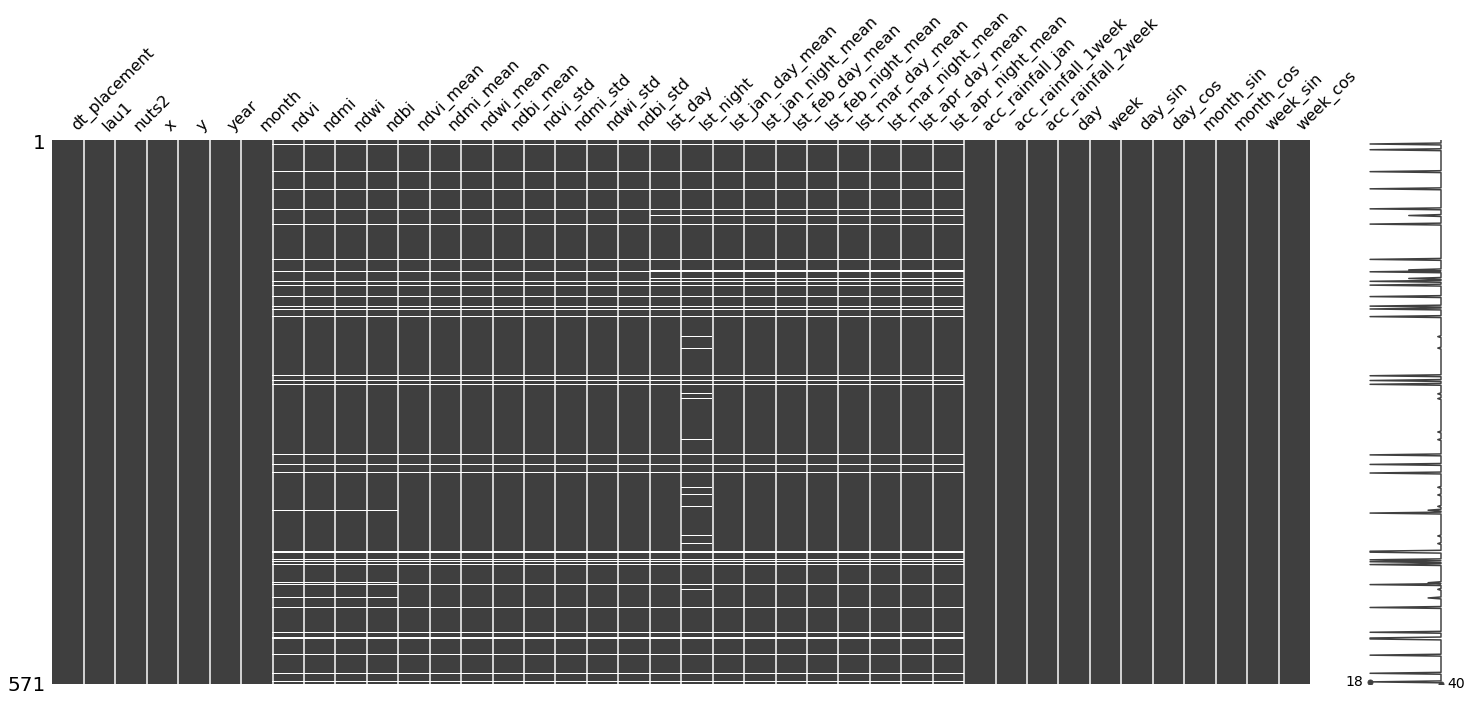

In [16]:
missingno.matrix(dataset)

In [17]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2010-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [18]:
mosquito_data.nuts2.unique()

array(['Veneto', 'Lombardia', 'Firuli-Venezia-Giulia',
       'Friuli-Venezia-Giulia'], dtype=object)

In [19]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'Veneto'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [20]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [21]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

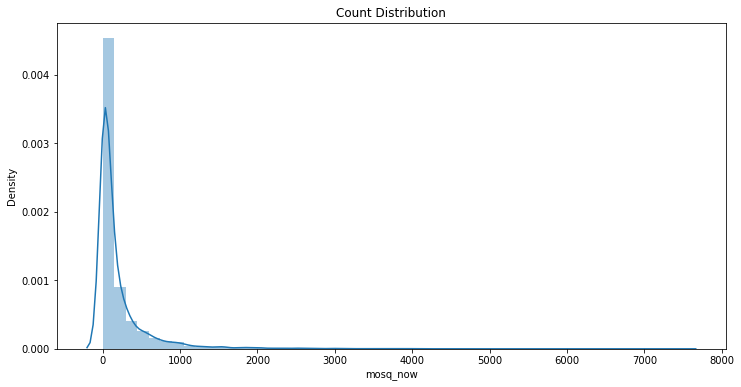

In [22]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [23]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

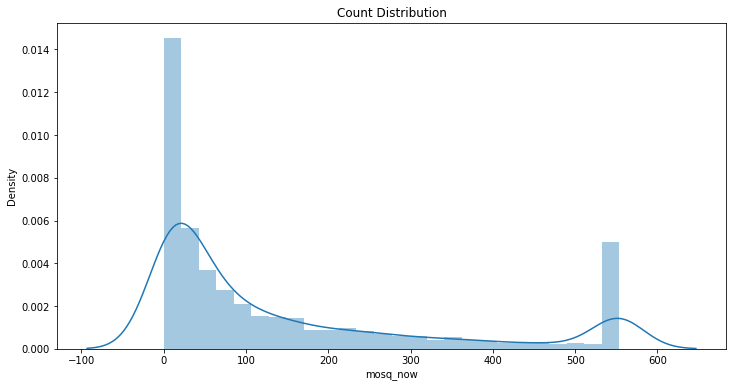

In [24]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

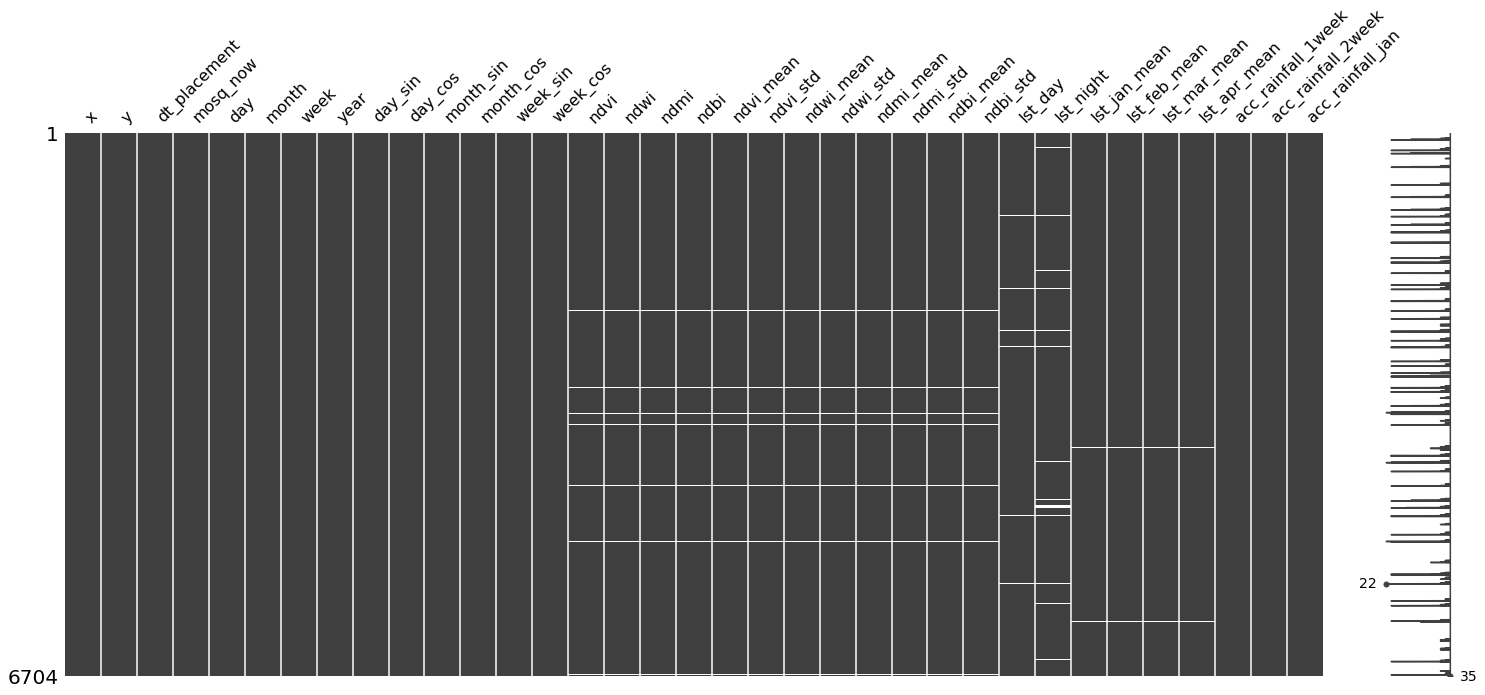

In [25]:
missingno.matrix(mosquito_data_nuts2)

In [26]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [27]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

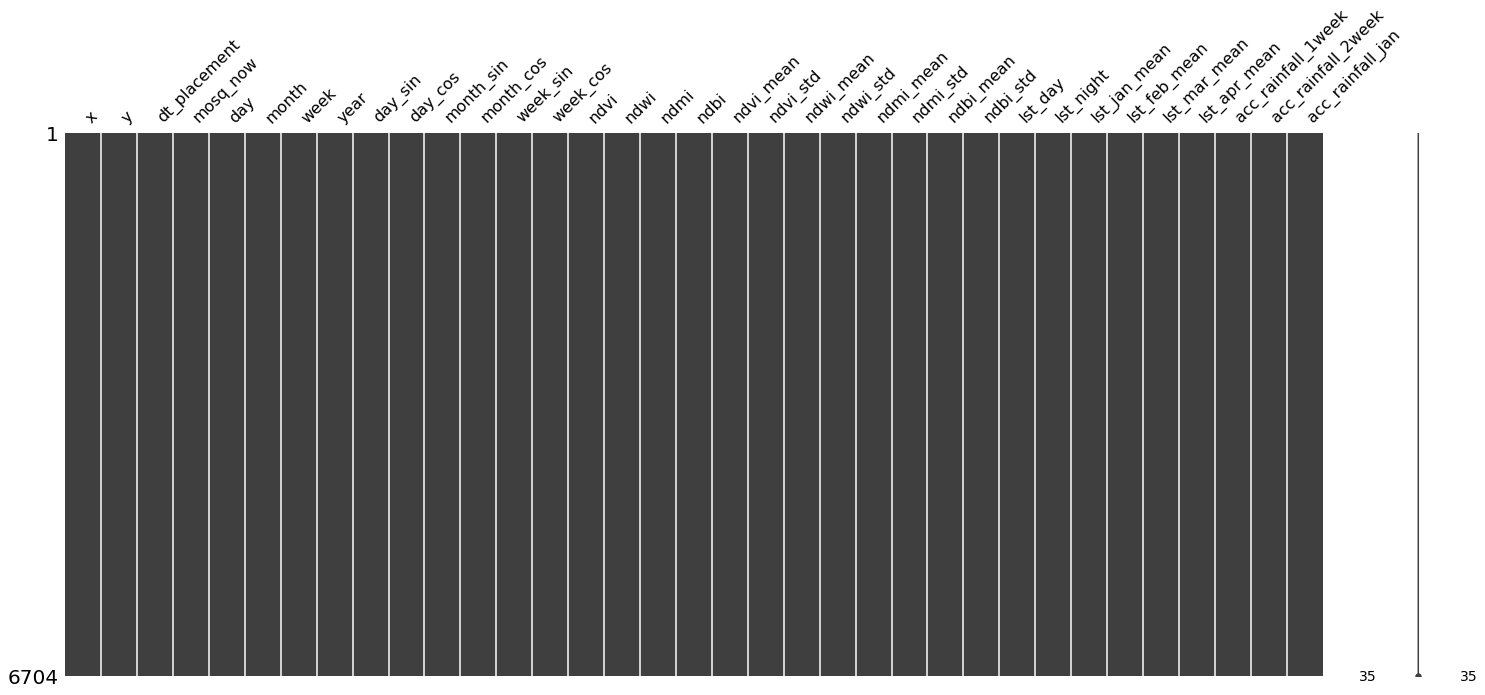

In [28]:
missingno.matrix(mosquito_data_nuts2)

In [29]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [30]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   61.  553.7]


In [31]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 8.60741 | Val Loss: 7.20825 | Train Acc: 2.144| Val Acc: 1.885
Epoch 002: | Train Loss: 5.58657 | Val Loss: 4.83119 | Train Acc: 1.564| Val Acc: 1.274
Epoch 003: | Train Loss: 6.13748 | Val Loss: 4.26458 | Train Acc: 1.668| Val Acc: 1.261
Epoch 004: | Train Loss: 5.84652 | Val Loss: 4.85698 | Train Acc: 1.573| Val Acc: 1.388
Epoch 005: | Train Loss: 5.22812 | Val Loss: 3.78676 | Train Acc: 1.455| Val Acc: 1.105
Epoch 006: | Train Loss: 5.35511 | Val Loss: 4.40149 | Train Acc: 1.476| Val Acc: 1.277
Epoch 007: | Train Loss: 5.06858 | Val Loss: 3.98143 | Train Acc: 1.414| Val Acc: 1.144
Epoch 008: | Train Loss: 4.92642 | Val Loss: 3.90459 | Train Acc: 1.393| Val Acc: 1.110
Epoch 009: | Train Loss: 4.90025 | Val Loss: 3.95044 | Train Acc: 1.383| Val Acc: 1.133
Epoch 010: | Train Loss: 4.78490 | Val Loss: 4.03926 | Train Acc: 1.366| Val Acc: 1.148
Epoch 011: | Train Loss: 4.66861 | Val Loss: 4.21324 | Train Acc: 1.346| Val Acc: 1.182
Epoch 012: | Train Loss: 4.60891

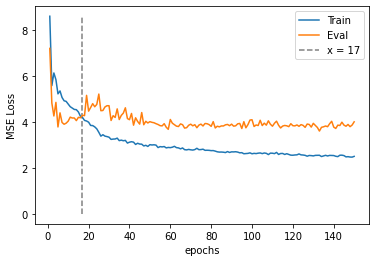

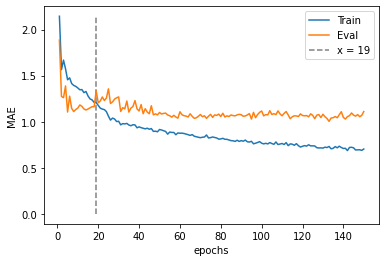

In [32]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [33]:
metrics(train, test, threshold=30)

MAE on train set:  83.07027333667068
min prediction: 1
max prediction: 640

MAE on test set:  96.11024949240114
Error ⩽ 30: 30.65 %
min prediction: 1
max prediction: 595


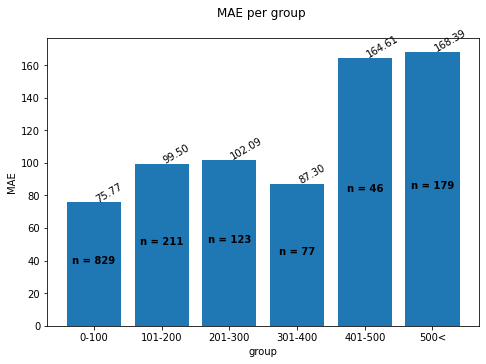

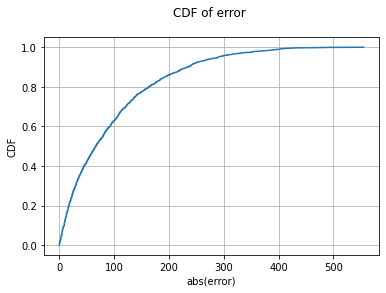

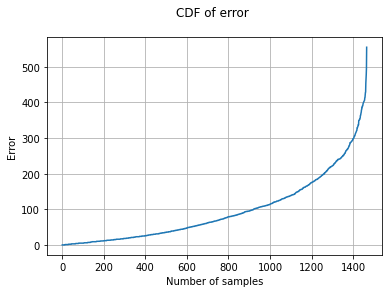

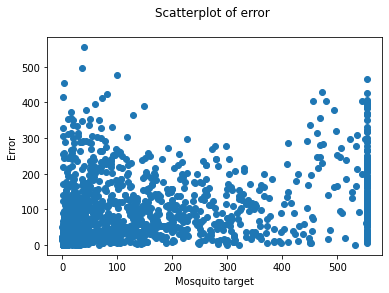

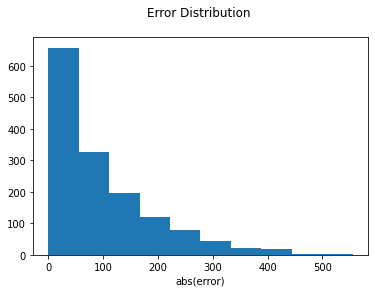

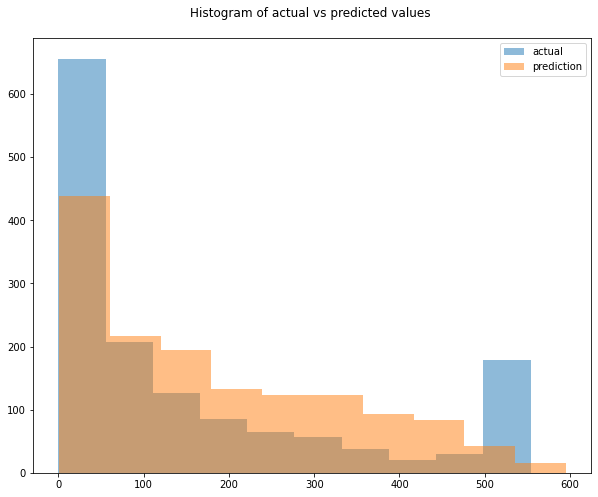

In [34]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 2.81732 | Val Loss: 0.34509 | Train Acc: 0.846| Val Acc: 0.394
Epoch 002: | Train Loss: 2.70997 | Val Loss: 0.29942 | Train Acc: 0.827| Val Acc: 0.394
Epoch 003: | Train Loss: 2.69517 | Val Loss: 0.87886 | Train Acc: 0.822| Val Acc: 1.394
Epoch 004: | Train Loss: 2.66116 | Val Loss: 0.35501 | Train Acc: 0.820| Val Acc: 0.394
Epoch 005: | Train Loss: 2.68294 | Val Loss: 0.37208 | Train Acc: 0.830| Val Acc: 0.394
Epoch 006: | Train Loss: 2.65108 | Val Loss: 0.56583 | Train Acc: 0.815| Val Acc: 0.394
Epoch 007: | Train Loss: 2.63271 | Val Loss: 0.18372 | Train Acc: 0.804| Val Acc: 0.394
Epoch 008: | Train Loss: 2.66904 | Val Loss: 0.24894 | Train Acc: 0.833| Val Acc: 0.394
Epoch 009: | Train Loss: 2.62192 | Val Loss: 0.79308 | Train Acc: 0.814| Val Acc: 0.394
Epoch 010: | Train Loss: 2.63382 | Val Loss: 0.33375 | Train Acc: 0.797| Val Acc: 0.394
Epoch 011: | Train Loss: 2.59796 | Val Loss: 0.50436 | Train Acc: 0.794| Val Acc: 0.394
Epoch 012: | Train Loss: 2.60583

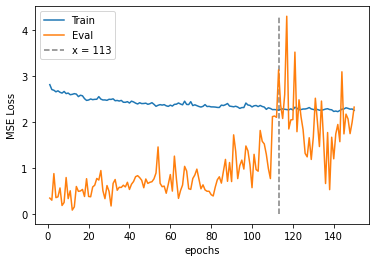

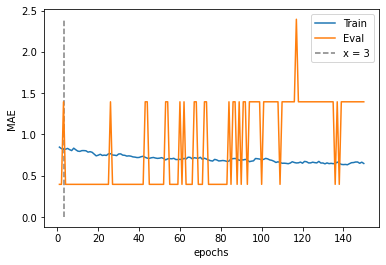

In [35]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [36]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [37]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [38]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [39]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [40]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [41]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

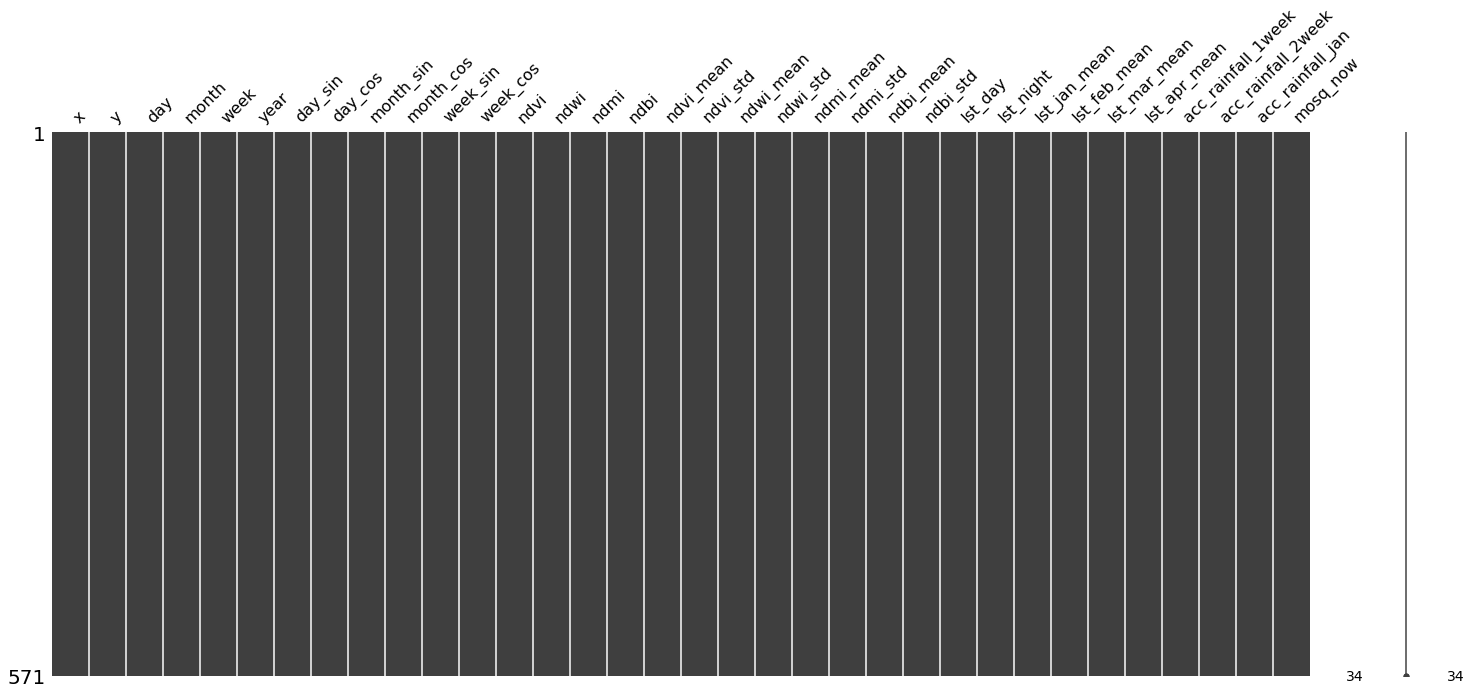

In [42]:
missingno.matrix(dataset_mamoth)

In [43]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [44]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [45]:
predictions = give_predictions(model, dataset_mamoth)

In [46]:
mosqutio_predictions['mosq_pred'] = predictions

In [47]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,11.795390,45.357830,2023-07-01,71
1,12.049403,45.070483,2023-07-01,146
2,10.776730,45.556800,2023-07-01,36
3,11.965390,45.175310,2023-07-01,153
4,12.059120,46.313990,2023-07-01,14
...,...,...,...,...
566,11.127335,45.353970,2023-07-01,159
567,11.358050,45.347770,2023-07-01,177
568,12.178780,46.388350,2023-07-01,13
569,11.494300,45.437980,2023-07-01,119


In [48]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-{MONTH}-{PERIOD}.csv', index = False)